# 3. Why, did regulation change it, and does it help forecasting?

This notebook looks at:
1. When in the day the expiry effect appears.
2. Whether the index is "pinned" to option strike prices.
3. Whether expiry-day moves reverse at the close (the pattern SEBI's July 2025 interim order alleged for Bank Nifty).
4. Whether the effect changed after SEBI's November 2024 measures and the July 2025 order, plus a first look at the August 2026 closing auction.
5. Whether weekly options raise total weekly volatility.
6. Whether knowing the expiry calendar improves next-day volatility forecasts (the link to paper 1).

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
from expiryvol import data, expiries as ex, estimate as es, mechanisms as me, forecast as fc, plots
from expiryvol.features import build_panel
DATA, RES, FIG = ROOT / "data", ROOT / "results", ROOT / "figures"
pct = lambda b: 100 * (np.exp(b) - 1)   # log-variance difference -> % change in variance

## 1. Timing within the day
- Each point is the expiry-day change in the variance of one 15-minute slot.
- The effect is small in the morning and grows through the afternoon. It peaks in 15:00–15:30, the half hour that set the settlement price.

**Note:** the slot effects measure a *typical* slot (they are averages of logs), so they don't add up to the whole-day number.

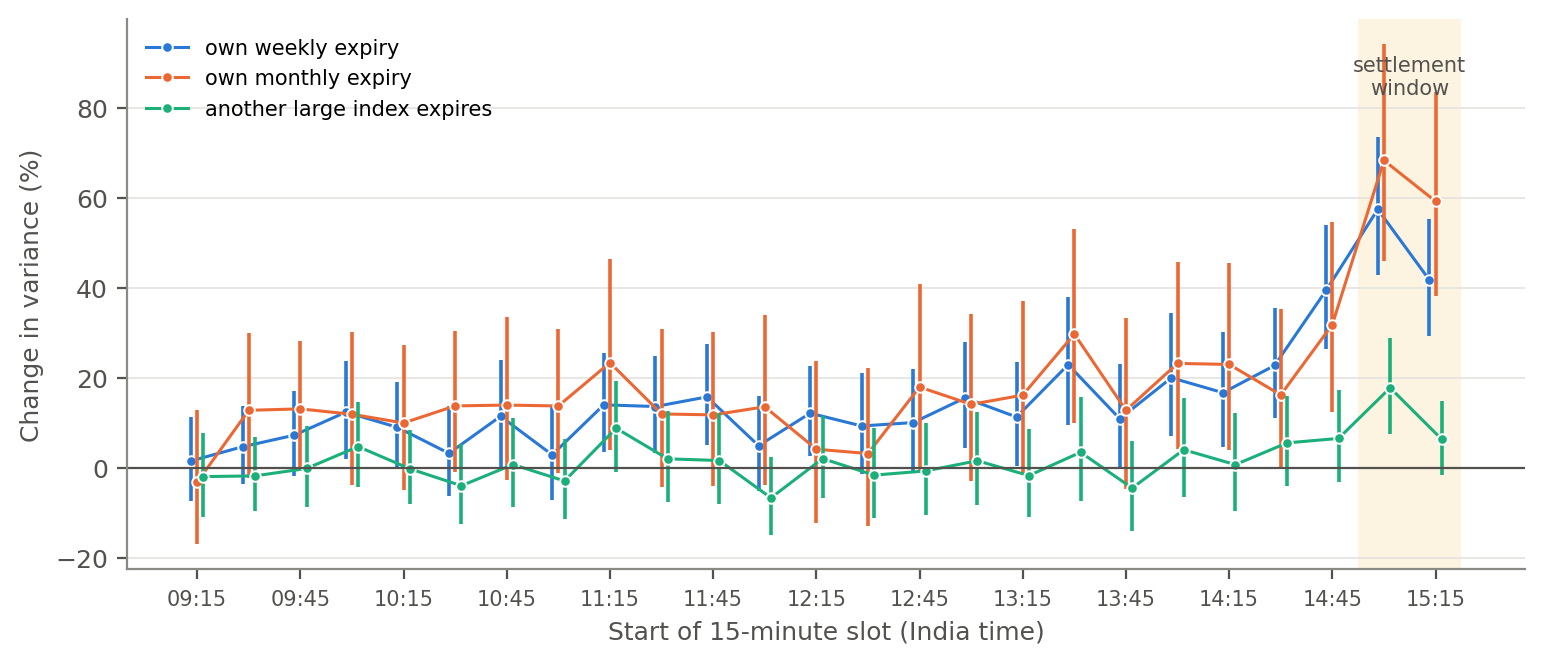

In [2]:
Image(FIG / 'fig4_intraday.png')

In [3]:
pd.read_csv(RES / 'slot_effects.csv').pivot(index='start', columns='term', values='coef').round(3)

term,other_major,own_monthly,own_weekly
start,,,
09:15,-0.019,-0.032,0.016
09:30,-0.018,0.120,0.046
09:45,-0.001,0.123,0.070
10:00,0.046,0.113,0.117
10:15,-0.002,0.095,0.086
10:30,-0.040,0.129,0.032
10:45,0.008,0.131,0.109
11:00,-0.029,0.129,0.029
11:15,0.085,0.210,0.131


## 2. Pinning to strikes
**Pinning** means the index tends to close exactly at, or near, an option strike price on expiry day.
- **Test A:** is the official close within 10% of a strike step of a round strike more often on expiry days? With no pinning, about 20% of closes should be that near.
- **Test B (Nifty, Bank Nifty):** does the index move *toward* the strike with the most open interest during expiry day, compared with other days?
- **Answer:** only weak signs, for Bank Nifty's 100-point strikes. There is no movement toward the most-held strike; on Nifty expiry days the index, if anything, moves away from it.

In [4]:
display(pd.read_csv(RES / 'pinning_grid.csv').round(3))
pd.read_csv(RES / 'pinning_maxoi.csv').round(3)

,index,step,share_expiry,share_other,n_expiry,coef_weekly,se_weekly,coef_monthly,se_monthly
0,nifty50,50,0.208,0.195,451,-0.003,0.033,-0.022,0.042
1,nifty50,100,0.211,0.184,451,0.028,0.034,-0.048,0.041
2,banknifty,100,0.228,0.199,491,0.075,0.032,0.107,0.044
3,banknifty,500,0.228,0.185,491,0.015,0.033,0.064,0.047
4,sensex,100,0.244,0.201,168,0.042,0.047,0.038,0.080
5,sensex,500,0.202,0.187,168,-0.005,0.043,-0.111,0.071


,index,coef,se,p,mean_move_expiry,mean_move_other,mean_close_dist_expiry,mean_close_dist_other,share_closer_expiry,share_closer_other,n_expiry,n
0,banknifty,0.098,0.066,0.134,0.222,0.152,1.950,2.743,0.432,0.438,486,3041
1,nifty50,0.107,0.052,0.038,0.201,0.110,1.502,1.945,0.368,0.433,443,3037


## 3. Do expiry-day moves reverse?
- `am_x_own`: does the afternoon undo the morning more on expiry days?
- `rest_x_own`: does the last half hour undo the rest of the day more on expiry days?
- For Bank Nifty in Jan 2023 – Mar 2025 (the period of SEBI's allegations), the last half hour does reverse the day's move on expiry days. This is one test among many, so treat it as suggestive.

In [5]:
rev = pd.read_csv(RES / "reversal.csv")
rev[rev["term"].isin(["am_x_own", "rest_x_own"])][["test", "sample", "term", "coef", "se", "p"]].round(3)

,test,sample,term,coef,se,p
1,afternoon on morning,pooled,am_x_own,0.090,0.078,0.252
4,last half hour on rest of day,pooled,rest_x_own,0.007,0.019,0.724
7,afternoon on morning,nifty50,am_x_own,0.091,0.112,0.419
10,last half hour on rest of day,nifty50,rest_x_own,-0.004,0.029,0.883
13,afternoon on morning,banknifty,am_x_own,0.072,0.102,0.482
16,last half hour on rest of day,banknifty,rest_x_own,0.031,0.030,0.293
19,afternoon on morning,sensex,am_x_own,0.158,0.109,0.148
22,last half hour on rest of day,sensex,rest_x_own,-0.025,0.029,0.380
25,afternoon on morning,banknifty 2023-01..2025-03,am_x_own,-0.001,0.128,0.991
28,last half hour on rest of day,banknifty 2023-01..2025-03,rest_x_own,-0.094,0.035,0.009


## 4. Did regulation shrink the effect?
- Within short periods, an index's expiry weekday rarely changes. So here we compare indices with each other on the same weekday.
- The settlement-window effect stayed large over time. It was somewhat lower right after SEBI's November 2024 measures, but still significant, and largest after the July 2025 interim order.
- The set of indices with weekly expiries also changed, so read these period numbers as descriptive.

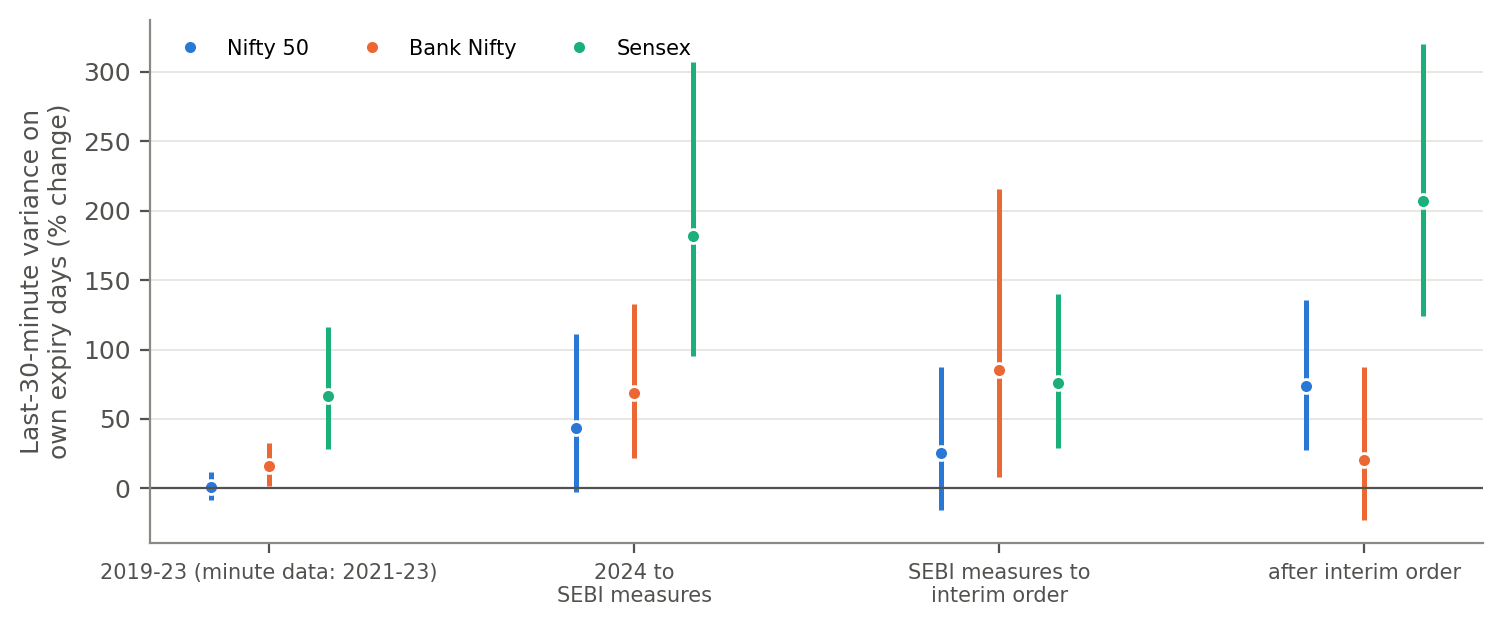

,sample,period,term,coef,se,p,n_treated
15,pooled,2019-23 (minute data: 2021-23),own_weekly,0.192,0.056,0.001,233
16,pooled,2019-23 (minute data: 2021-23),own_monthly,0.383,0.093,0.000,72
17,pooled,2019-23 (minute data: 2021-23),other_major,-0.000,0.075,0.996,417
18,pooled,2024 to SEBI measures,own_weekly,0.603,0.186,0.002,108
19,pooled,2024 to SEBI measures,own_monthly,0.714,0.180,0.000,30
20,pooled,2024 to SEBI measures,other_major,0.226,0.190,0.240,266
21,pooled,SEBI measures to interim order,own_weekly,0.494,0.187,0.013,49
22,pooled,SEBI measures to interim order,own_monthly,0.312,0.131,0.023,24
23,pooled,SEBI measures to interim order,other_major,0.258,0.152,0.100,140
24,pooled,after interim order,own_weekly,0.921,0.169,0.000,80


In [6]:
display(Image(FIG / 'fig6_periods.png'))
per = pd.read_csv(RES / 'period_effects.csv')
per[per['outcome'] == 'lrv_last'][['sample', 'period', 'term', 'coef', 'se', 'p', 'n_treated']].round(3)

**The closing auction (from 3 Aug 2026), first look.**
- With only about two months of hourly data, the test has very little power.
- There is no sign yet that the expiry-day effect in the last bar of the day went away.

In [7]:
pd.read_csv(RES / 'closing_auction_hourly.csv').round(3)

,term,coef,se,t,p,lo,hi,sample,n,post_days,post_expiries
0,own,0.377,0.082,4.620,0.000,0.216,0.538,pooled,2163,126,21
1,other_major,0.210,0.072,2.914,0.004,0.068,0.353,pooled,2163,126,21
2,own_x_post,0.994,0.415,2.397,0.018,0.175,1.813,pooled,2163,126,21
3,other_x_post,0.080,0.394,0.203,0.840,-0.699,0.859,pooled,2163,126,21
4,own,0.612,0.103,5.948,0.000,0.409,0.815,banknifty,721,42,2
5,other_major,0.127,0.096,1.320,0.189,-0.063,0.316,banknifty,721,42,2
6,own_x_post,0.350,1.305,0.268,0.789,-2.228,2.928,banknifty,721,42,2
7,own,0.436,0.102,4.263,0.000,0.234,0.638,nifty50,721,42,10
8,other_major,0.291,0.069,4.243,0.000,0.156,0.427,nifty50,721,42,10
9,own_x_post,0.159,0.738,0.215,0.830,-1.299,1.617,nifty50,721,42,10


## 5. Do weekly options raise *total* weekly volatility?
- The simple comparison says yes, by about 5%.
- But the effect disappears once each index's own long-run trend is allowed for. Treat this as "no reliable evidence".

In [8]:
pd.read_csv(RES / 'weekly_totals.csv').round(3)

,measure,coef,se,t,p,lo,hi,n
0,close-to-close,0.054,0.017,3.113,0.002,0.020,0.088,2510
1,session (Garman-Klass),0.056,0.017,3.255,0.001,0.022,0.090,2510
2,"close-to-close, + index-specific trends",-0.018,0.017,-1.039,0.299,-0.051,0.016,2510


## 6. Forecasting (link to paper 1)
- Paper 1's HAR model, with the expiry calendar of the next day added as inputs, tested walk-forward from 2018.
- Adding the calendar makes forecasts slightly *worse* (QLIKE up about 1–2%).
- This fits Result 1: whole-day volatility hardly changes on expiry days. The effect sits in the last half hour, which a daily model doesn't see.

In [9]:
pd.read_csv(RES / 'forecast.csv').round(4)

,index,subset,n,qlike_base,qlike_alt,qlike_change_pct,dm_t,dm_p,mse_change_pct,dm_t_mse,dm_p_mse
0,nifty50,all days,2107,0.3702,0.3754,1.4201,2.0683,0.0386,0.6692,1.0779,0.2811
1,nifty50,own expiry next day,403,0.3389,0.3523,3.9309,1.0675,0.2857,5.1968,0.9944,0.3200
2,banknifty,all days,2109,0.3581,0.3645,1.8104,1.8661,0.0620,1.4817,1.1747,0.2401
3,banknifty,own expiry next day,380,0.3673,0.3951,7.5792,1.5337,0.1251,7.0143,1.0276,0.3041
4,sensex,all days,2105,0.3756,0.3792,0.9736,2.4894,0.0128,0.6290,1.0848,0.2780
5,sensex,own expiry next day,168,0.3724,0.3886,4.3529,1.6741,0.0941,9.2410,1.6717,0.0946
6,midcap50,all days,2100,0.3468,0.3474,0.1841,0.2498,0.8027,0.6063,0.7550,0.4503
7,midcap50,own expiry next day,167,0.3425,0.3572,4.2999,0.8160,0.4145,8.8217,1.1116,0.2663
